# Common Task III: Contrastive Learning
Contrastive learning improves representation quality without labels.
Learned embeddings enable effective downstream classification.

In [1]:
import os; os.chdir('/Users/sasisundar/Desktop/ml4sci-gsoc/ml4sci-gsoc')
import sys; sys.path.insert(0, '.')
import warnings; warnings.filterwarnings('ignore')


In [2]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from src.models.contrastive import ContrastiveModel
from src.data.loader import JetDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

dataset = JetDataset('dataset.hdf5', max_samples=10000)
model = ContrastiveModel().to(device)
model.load_state_dict(torch.load('outputs/models/contrastive.pt', map_location=device, weights_only=True))
model.eval()

X, y = [], []
print('Extracting embeddings...')
for i in range(len(dataset)):
    img, label = dataset[i]
    with torch.no_grad():
        h, _ = model(img.unsqueeze(0).to(device))
    X.append(h.cpu().numpy().flatten())
    y.append(label.item())

X = np.array(X)
y = np.array(y)

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

class MLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d, 128), nn.ReLU(), nn.Linear(128, 2))
    def forward(self, x): return self.net(x)

clf = MLP(X_train.shape[1]).to(device)
opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()
Xt = torch.tensor(X_train, dtype=torch.float32).to(device)
yt = torch.tensor(y_train, dtype=torch.long).to(device)

print('Training MLP downstream classifier...')
for ep in range(50):
    o = clf(Xt); l = crit(o, yt); opt.zero_grad(); l.backward(); opt.step()

Xte = torch.tensor(X_test, dtype=torch.float32).to(device)
with torch.no_grad():
    o = clf(Xte)
    probs = torch.softmax(o, dim=1)[:,1].cpu().numpy()
    preds = torch.argmax(o, dim=1).cpu().numpy()

print(f'Test Accuracy: {accuracy_score(y_test, preds):.4f}')
print(f'Test ROC AUC: {roc_auc_score(y_test, probs):.4f}')


Device: cpu


Extracting embeddings...


Training MLP downstream classifier...
Test Accuracy: 0.7230
Test ROC AUC: 0.7924


## t-SNE Embedding Visualization
Projecting high-dimensional contrastive embeddings into 2D to verify class separation.

Running t-SNE...


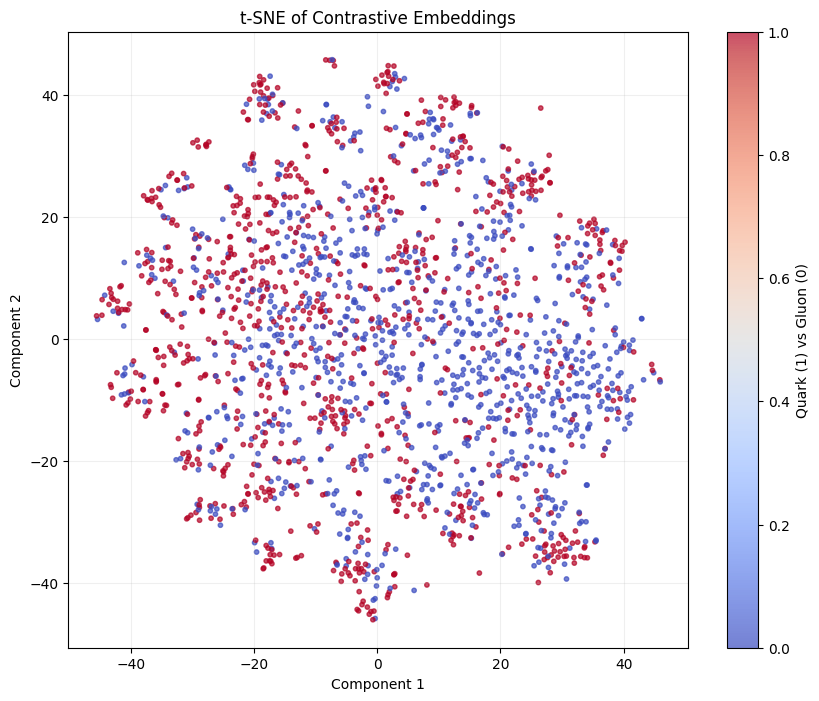

t-SNE plot saved.


In [3]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

print('Running t-SNE...')
X_emb = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X[:2000])
y_sub = y[:2000]

plt.figure(figsize=(10, 8))
sc = plt.scatter(X_emb[:, 0], X_emb[:, 1], c=y_sub, cmap='coolwarm', s=10, alpha=0.7)
plt.colorbar(sc, label='Quark (1) vs Gluon (0)')
plt.title('t-SNE of Contrastive Embeddings')
plt.xlabel('Component 1'); plt.ylabel('Component 2')
plt.grid(alpha=0.2)
plt.savefig('outputs/plots/tsne.png', dpi=150)
plt.show()
print('t-SNE plot saved.')
